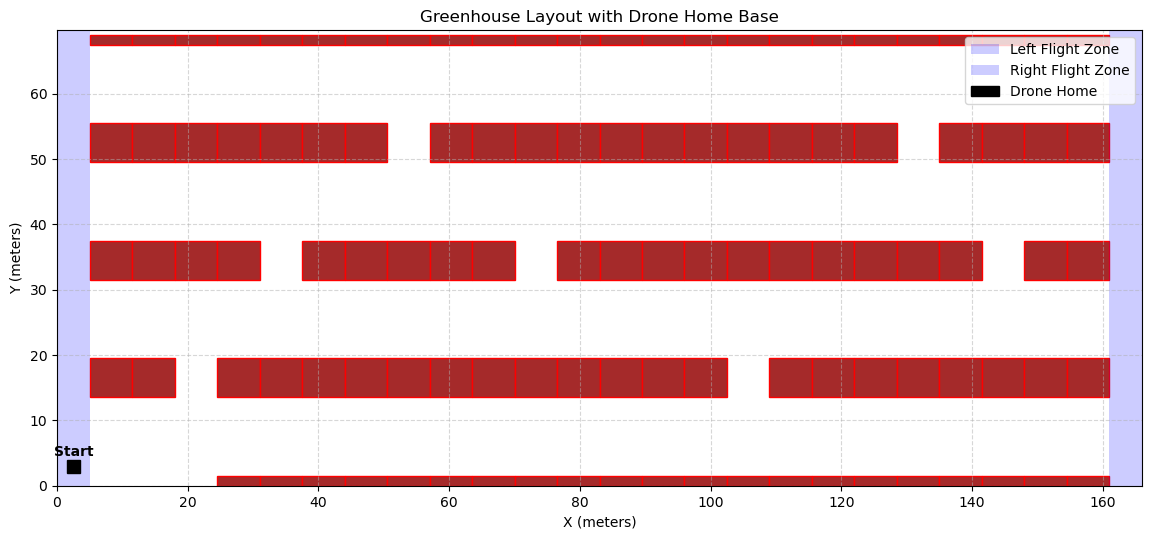

In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# --- 1. 定義基礎參數 ---
ROOM_WIDTH = 166  # 溫室寬 (x)
ROOM_HEIGHT = 69.7  # 溫室高 (y)

# 關鍵修改：定義起始偏移量 (左邊界)
LEFT_MARGIN = 5

# 盆栽尺寸
POT_LENGTH = 6.5  # 盆栽長度 (x方向)
GAP_X = 0       # 盆栽之間的左右間隔

# 行高定義
SINGLE_ROW_H = 1.5 
DOUBLE_ROW_H = 6.0 

# Y 軸起始位置
ROW_Y_COORDS = [67.5, 49.5, 31.5, 13.5, 0.0] 

# --- 2. 建立障礙物列表 (Obstacles) ---
obstacles = []

def add_pot(row_index, pot_index, is_double=False):
    """
    row_index: 第幾排 (0~4)
    pot_index: 該排的第幾個盆栽 (0~23)
    """
    # 關鍵修改：X 座標 = 左邊界 + ( (盆栽長+間隔) * 第幾個 )
    current_x = LEFT_MARGIN + (POT_LENGTH + GAP_X) * pot_index
    
    current_y = ROW_Y_COORDS[row_index]
    current_h = DOUBLE_ROW_H if is_double else SINGLE_ROW_H
    
    pot_data = {
        'x': current_x,
        'y': current_y,
        'w': POT_LENGTH,
        'h': current_h,
        'label': f"R{row_index+1}_P{pot_index+1}"
    }
    return pot_data

# --- 批量生成盆栽 (每排預設 24 顆) ---
# range(0, 24) 代表 index 0 到 23，共 24 顆
# 這樣最右邊會剛好剩下約 4.5m 的空間

# Row 1 (最上面, 單排)
for i in range(0, 24):
    # 這裡可以加入你要刪除的特定盆栽 (例如空出通道)
    # if i == 5: continue 
    obstacles.append(add_pot(0, i, is_double=False))

# Row 2 (中間, 雙排)
for i in range(0, 24):
    # 保留你的範例刪除法：
    if i == 7 or i == 19:continue
    obstacles.append(add_pot(1, i, is_double=True))

# Row 3 (中間, 雙排)
for i in range(0, 24):
    if i == 4 or i == 10 or i == 21: continue
    obstacles.append(add_pot(2, i, is_double=True))

# Row 4 (中間, 雙排)
for i in range(0, 24):
    if i == 2 or i == 15: continue
    obstacles.append(add_pot(3, i, is_double=True))

# Row 5 (最下面, 單排)
for i in range(3, 24):
    obstacles.append(add_pot(4, i, is_double=False))


# --- 3. 畫出來檢查 (視覺化) ---
fig, ax = plt.subplots(figsize=(14, 7))

# 畫邊界
ax.set_xlim(0, ROOM_WIDTH)
ax.set_ylim(0, ROOM_HEIGHT)

# A. 畫盆栽 (紅色障礙物)
for ob in obstacles:
    rect = patches.Rectangle((ob['x'], ob['y']), ob['w'], ob['h'], linewidth=1, edgecolor='r', facecolor='brown')
    ax.add_patch(rect)

# B. 畫左/右飛行區 (淺藍色背景)
# 左飛行區
rect_left = patches.Rectangle((0, 0), LEFT_MARGIN, ROOM_HEIGHT, alpha=0.2, facecolor='blue', label='Left Flight Zone')
ax.add_patch(rect_left)

# 右飛行區
last_pot_end_x = LEFT_MARGIN + (POT_LENGTH + GAP_X) * 23 + POT_LENGTH 
rect_right = patches.Rectangle((last_pot_end_x, 0), ROOM_WIDTH - last_pot_end_x, ROOM_HEIGHT, alpha=0.2, facecolor='blue', label='Right Flight Zone')
ax.add_patch(rect_right)

# C. [新增] 畫無人機起飛點 (黑色 2x2m)
# 設定位置：左下角通道置中 (X=2, Y=3)
base_size = 2.0
base_x = (LEFT_MARGIN / 2) - (base_size / 2) # 算出的起點 X = 1.0
base_y = 3.0 - (base_size / 2)               # 算出的起點 Y = 2.0

home_base = patches.Rectangle(
    (base_x, base_y), 
    base_size, 
    base_size, 
    edgecolor='black', 
    facecolor='black', 
    label='Drone Home'
)
ax.add_patch(home_base)
ax.text(LEFT_MARGIN/2, 3.0 + 1.5, "Start", color='black', fontsize=10, ha='center', weight='bold')


plt.title(f"Greenhouse Layout with Drone Home Base")
plt.xlabel("X (meters)")
plt.ylabel("Y (meters)")
plt.legend(loc='upper right') # 圖例改右上角比較不會擋到
plt.grid(True, linestyle='--', alpha=0.5)
plt.gca().set_aspect('equal', adjustable='box')
plt.show()

🚧 正在生成高密度安全網格 (解析度 0.5m, 安全緩衝 1.2m)...
✅ 安全網格建立完成：21942 個節點
🧮 計算關鍵點距離 (Dijkstra)...
🚀 啟動 ACO...
Iter 10: Best 1217.1m
Iter 20: Best 1190.0m
Iter 30: Best 1181.6m
Iter 40: Best 1181.6m
Iter 50: Best 1181.6m
Iter 60: Best 1181.6m
Iter 70: Best 1163.8m
Iter 80: Best 1163.8m
Iter 90: Best 1163.8m
Iter 100: Best 1163.8m


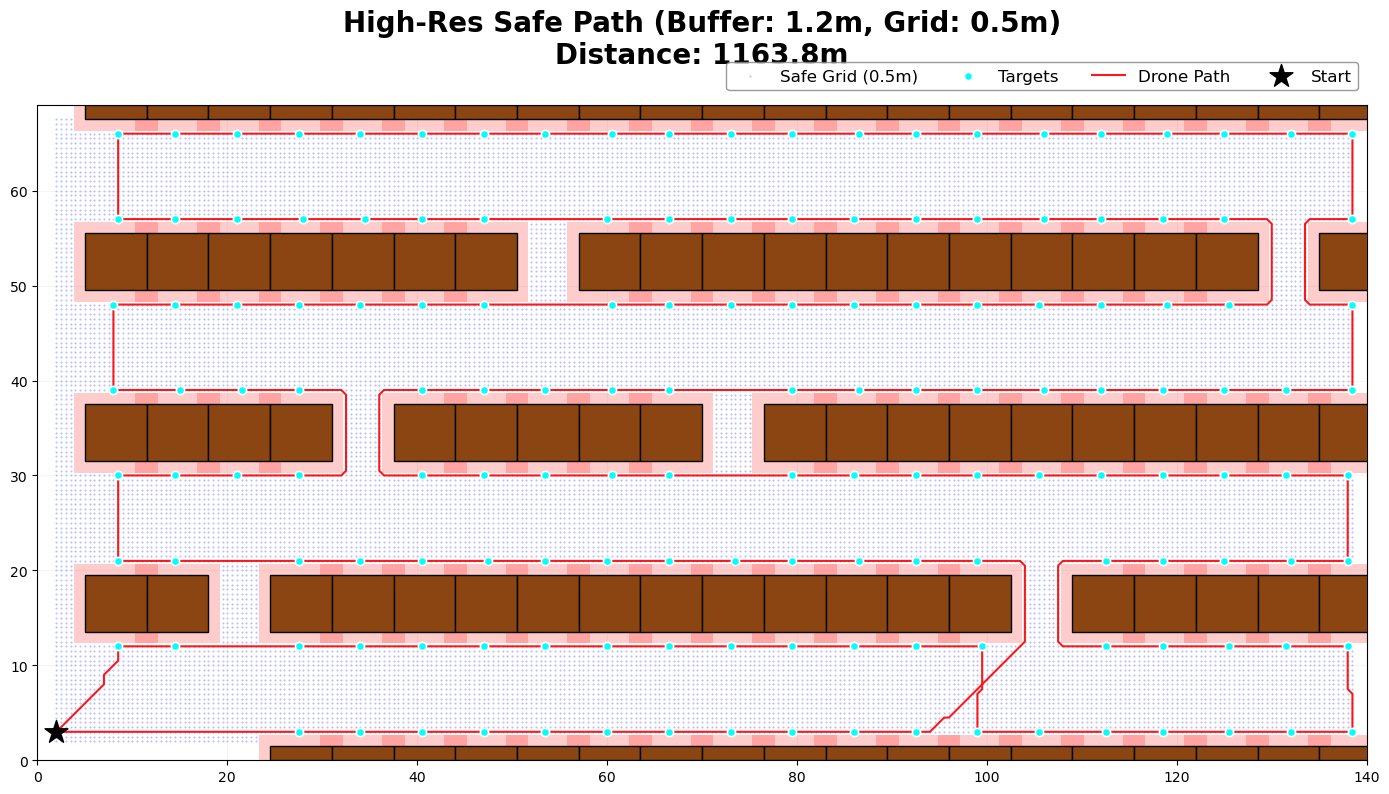

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd
from scipy.spatial import distance
import networkx as nx
import time

# ==========================================
# 1. 環境設定 (含安全膨脹)
# ==========================================
class GreenhouseSafeGrid:
    def __init__(self):
        self.width = 166
        self.height = 69.7
        self.left_margin_pots = 5.0
        self.pot_length = 6.5
        self.gap_x = 0
        self.obstacles = []
        self._build_obstacles()
        
        # [關鍵參數]
        # GRID_RES: 網格密度 (越小路徑越細緻)
        self.GRID_RES = 0.5
        # SAFETY_BUFFER: 安全緩衝 (無人機半徑 + 誤差容許值)
        # 設為 1.2m，代表無人機中心點絕對不會離盆栽小於120公分
        self.SAFETY_BUFFER = 1.2 

    def _add_pot(self, row_index, pot_index, is_double):
        single_h = 1.5
        double_h = 6.0 
        row_y_coords = [67.5, 49.5, 31.5, 13.5, 0.0]
        
        current_x = self.left_margin_pots + (self.pot_length + self.gap_x) * pot_index
        current_y = row_y_coords[row_index]
        current_h = double_h if is_double else single_h
        
        return {
            'x': current_x, 'y': current_y,
            'w': self.pot_length, 'h': current_h,
            'cx': current_x + self.pot_length / 2,
            'cy': current_y + current_h / 2,
            'is_double': is_double,
            'row_idx': row_index,
            'id': f"R{row_index}_P{pot_index}"
        }

    def _build_obstacles(self):
        skipped = {
            0: [],
            1: [7, 19],
            2: [4, 10, 21],
            3: [2, 15],
            4: [0, 1, 2]
        }
        for r in range(5):
            is_dbl = (r in [1, 2, 3])
            start_idx = 0 
            for i in range(start_idx, 24):
                if i in skipped.get(r, []): continue
                self.obstacles.append(self._add_pot(r, i, is_dbl))

    def generate_safe_graph(self):
        G = nx.Graph()
        
        # 生成高密度網格
        x_range = np.arange(2.0, self.width, self.GRID_RES)
        y_range = np.arange(2.0, self.height, self.GRID_RES)
        
        node_id_counter = 0
        print(f"🚧 正在生成高密度安全網格 (解析度 {self.GRID_RES}m, 安全緩衝 {self.SAFETY_BUFFER}m)...")
        
        # 1. 篩選安全點
        for x in x_range:
            for y in y_range:
                # 這裡的檢查非常嚴格，不安全的點直接丟棄
                if self._is_safe_strict(x, y):
                    G.add_node(node_id_counter, pos=(x, y), type='connector')
                    node_id_counter += 1
        
        # 2. 建立連線
        coords = np.array([G.nodes[i]['pos'] for i in G.nodes])
        # 使用 KDTree 加速搜尋 (因為點變多了)
        from scipy.spatial import cKDTree
        tree = cKDTree(coords)
        
        # 連結半徑設為 1.5 倍網格距，確保對角線
        radius = self.GRID_RES * 1.5
        pairs = tree.query_pairs(r=radius)
        
        for i, j in pairs:
            # 再次檢查連線安全性 (避免切角撞到膨脹區)
            p1 = G.nodes[i]['pos']
            p2 = G.nodes[j]['pos']
            if not self._is_line_blocked(p1, p2):
                dist = np.linalg.norm(np.array(p1) - np.array(p2))
                G.add_edge(i, j, weight=dist)
                
        print(f"✅ 安全網格建立完成：{len(G.nodes)} 個節點")
        return G

    def identify_targets(self, G):
        target_ids = set()
        offset = 1.0 # 理想觀察距離
        
        node_ids = list(G.nodes)
        node_coords = np.array([G.nodes[i]['pos'] for i in node_ids])
        
        # 使用 KDTree 加速最近鄰搜索
        from scipy.spatial import cKDTree
        tree = cKDTree(node_coords)
        
        for ob in self.obstacles:
            ideal_spots = []
            if ob['row_idx'] != 4: 
                ideal_spots.append((ob['cx'], ob['y'] - offset))
            if ob['is_double'] or ob['row_idx'] == 4:
                ideal_spots.append((ob['cx'], ob['y'] + ob['h'] + offset))
                
            for tx, ty in ideal_spots:
                # 找最近的「安全網格點」
                dist, idx = tree.query((tx, ty))
                
                # 這裡不需要檢查 dist < 3.0，因為如果最近的點都很遠，
                # 代表那個位置根本進不去(被緩衝區填滿了)，那就自然放棄該點，確保安全
                if dist < 2.0:
                    real_node_id = node_ids[idx]
                    G.nodes[real_node_id]['type'] = 'target'
                    target_ids.add(real_node_id)

        # 起點
        d, start_idx = tree.query((2.0, 3.0))
        start_id = node_ids[start_idx]
        G.nodes[start_id]['type'] = 'start'
        
        return list(target_ids), start_id

    def _is_safe_strict(self, x, y):
        # 嚴格檢查：點必須在所有盆栽的 (邊界 + 緩衝區) 之外
        margin = self.SAFETY_BUFFER
        
        # 邊界檢查
        if not (margin < x < 140-margin and margin < y < 69-margin): return False
        
        for ob in self.obstacles:
            if (ob['x'] - margin < x < ob['x'] + ob['w'] + margin) and \
               (ob['y'] - margin < y < ob['y'] + ob['h'] + margin):
                return False
        return True

    def _is_line_blocked(self, p1, p2):
        # 線段檢查也要考慮膨脹
        steps = 3
        for t in np.linspace(0, 1, steps):
            px = p1[0] + (p2[0] - p1[0]) * t
            py = p1[1] + (p2[1] - p1[1]) * t
            # 直接呼叫 _is_safe_strict 檢查中間點
            if not self._is_safe_strict(px, py):
                return True
        return False

# ==========================================
# 2. ACO (保持不變，參數優化)
# ==========================================
class HighResACO:
    def __init__(self, G, target_ids, start_id, n_ants, n_iterations):
        self.G = G
        self.target_ids = target_ids
        self.start_id = start_id
        self.all_key_nodes = [start_id] + target_ids
        self.n_ants = n_ants
        self.n_iterations = n_iterations
        
        print("🧮 計算關鍵點距離 (Dijkstra)...")
        self.dist_matrix = self._compute_key_distances()
        
        self.n_keys = len(self.all_key_nodes)
        self.pheromone = np.ones((self.n_keys, self.n_keys))
        self.id_to_idx = {node_id: i for i, node_id in enumerate(self.all_key_nodes)}

    def _compute_key_distances(self):
        n = len(self.all_key_nodes)
        matrix = np.full((n, n), np.inf)
        for i, source_id in enumerate(self.all_key_nodes):
            length_dict = nx.single_source_dijkstra_path_length(self.G, source_id)
            for j, target_id in enumerate(self.all_key_nodes):
                if target_id in length_dict:
                    matrix[i][j] = length_dict[target_id]
        return matrix

    def run(self):
        best_tour = None
        best_len = np.inf
        
        # 啟發式
        with np.errstate(divide='ignore'):
            eta = 1.0 / self.dist_matrix
        eta[self.dist_matrix == np.inf] = 0
        
        start_idx = self.id_to_idx[self.start_id]
        
        print(f"🚀 啟動 ACO...")
        for it in range(self.n_iterations):
            paths = []
            lengths = []
            for _ in range(self.n_ants):
                tour = self._construct_tour(start_idx, eta)
                l = sum([self.dist_matrix[tour[k]][tour[k+1]] for k in range(len(tour)-1)])
                paths.append(tour)
                lengths.append(l)
                if l < best_len:
                    best_len = l
                    best_tour = tour
            
            self._update_pheromone(paths, lengths)
            if (it+1) % 10 == 0: print(f"Iter {it+1}: Best {best_len:.1f}m")
            
        return best_tour, best_len

    def _construct_tour(self, start_idx, eta):
        path = [start_idx]
        curr = start_idx
        unvisited = set(range(len(self.all_key_nodes)))
        unvisited.remove(start_idx)
        
        alpha, beta = 1.0, 4.0
        
        while unvisited:
            probs = []
            candidates = list(unvisited)
            for cand in candidates:
                ph = self.pheromone[curr][cand]
                he = eta[curr][cand]
                probs.append((ph**alpha) * (he**beta))
            
            probs = np.array(probs)
            if probs.sum() == 0: break
            probs /= probs.sum()
            
            next_idx = np.random.choice(candidates, p=probs)
            path.append(next_idx)
            unvisited.remove(next_idx)
            curr = next_idx
            
        path.append(start_idx)
        return path

    def _update_pheromone(self, paths, lengths):
        self.pheromone *= 0.9
        for p, l in zip(paths, lengths):
            deposit = 1000.0 / l
            for i in range(len(p)-1):
                u, v = p[i], p[i+1]
                self.pheromone[u, v] += deposit
                self.pheromone[v, u] += deposit

    def reconstruct_path(self, tour_indices):
        coords = []
        for k in range(len(tour_indices)-1):
            u = self.all_key_nodes[tour_indices[k]]
            v = self.all_key_nodes[tour_indices[k+1]]
            path_nodes = nx.shortest_path(self.G, u, v, weight='weight')
            for nid in path_nodes[:-1]:
                coords.append(self.G.nodes[nid]['pos'])
        coords.append(self.G.nodes[self.all_key_nodes[tour_indices[-1]]]['pos'])
        return np.array(coords)

# ==========================================
# 3. 執行
# ==========================================
env = GreenhouseSafeGrid()

# 1. 建立安全網格
G = env.generate_safe_graph()

# 2. 標定目標
targets, start_id = env.identify_targets(G)

# 3. ACO
aco = HighResACO(G, targets, start_id, n_ants=100, n_iterations=100)
best_indices, best_len = aco.run()
full_path = aco.reconstruct_path(best_indices)

# ... (前面省略 ACO 運算與環境設定代碼) ...



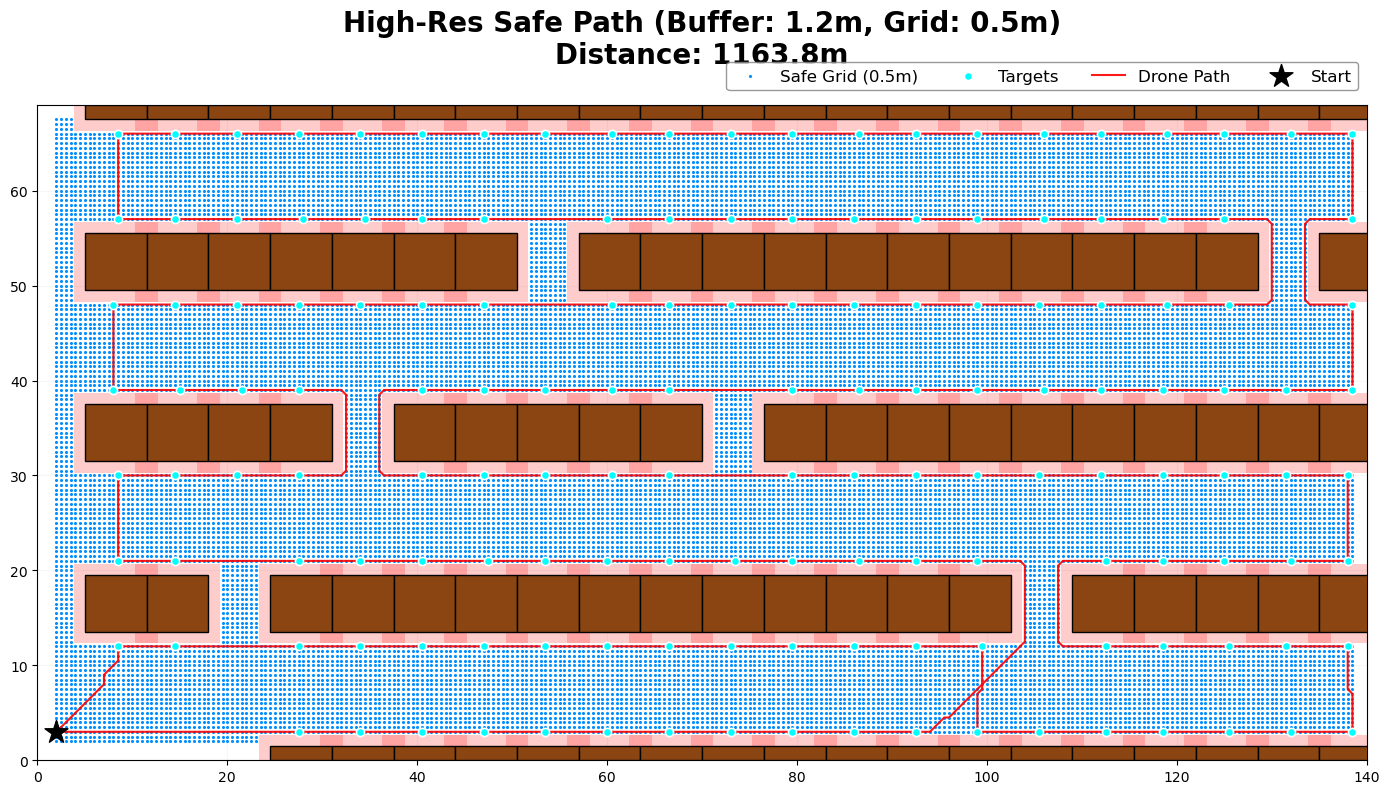

In [26]:
# --- 繪圖 (視覺化優化版) ---
fig, ax = plt.subplots(figsize=(14, 9)) # 高度稍微拉高一點 (8 -> 9)，避免標題被切掉
ax.set_xlim(0, 140)
ax.set_ylim(0, 69)

# 1. 畫盆栽與安全緩衝區
for ob in env.obstacles:
    rect = patches.Rectangle((ob['x'], ob['y']), ob['w'], ob['h'], 
                            facecolor='#8B4513', edgecolor='black', zorder=5)
    ax.add_patch(rect)
    
    margin = env.SAFETY_BUFFER
    buffer_rect = patches.Rectangle((ob['x']-margin, ob['y']-margin), 
                                    ob['w']+2*margin, ob['h']+2*margin, 
                                    facecolor='red', alpha=0.2, zorder=2, linestyle='--')
    ax.add_patch(buffer_rect)

# 2. 畫高密度網格
all_pos = np.array([G.nodes[i]['pos'] for i in G.nodes])
ax.scatter(all_pos[:,0], all_pos[:,1], c="#008FFD", s=1.5, alpha=1, label='Safe Grid (0.5m)')

# 3. 畫目標
tar_pos = np.array([G.nodes[i]['pos'] for i in targets])
ax.scatter(tar_pos[:,0], tar_pos[:,1], c='cyan', s=35, edgecolors='white', linewidth=1.2, zorder=15, label='Targets')

# 4. 畫路徑
ax.plot(full_path[:,0], full_path[:,1], c='red', linewidth=1.5, alpha=0.9, zorder=10, label='Drone Path')

# 5. 畫起點
start_pos = G.nodes[start_id]['pos']
ax.scatter(start_pos[0], start_pos[1], c='black', marker='*', s=300, zorder=20, label='Start')

# --- 關鍵修改區域 ---

# 設定標題：字體加大 (fontsize=20)，位置稍微上移 (pad=20)
plt.title(f"High-Res Safe Path (Buffer: {env.SAFETY_BUFFER}m, Grid: {env.GRID_RES}m)\nDistance: {best_len:.1f}m", 
          fontsize=20, fontweight='bold', pad=30) # pad 加大，把標題往上推，讓出空間給圖例

# 設定圖例：移到右上角外側 (跟標題同一層)
# bbox_to_anchor=(1.0, 1.02): 把錨點設在圖表右上角再往上一點點的地方
# loc='lower right': 讓圖例盒子的「右下角」對準那個錨點
# ncol=4: 讓圖例橫向排列 (這樣比較扁，不會擋到標題)，你可以視情況改成 1 (直排)
plt.legend(loc='lower right', bbox_to_anchor=(1.0, 1.01), 
           fontsize=12, ncol=5, frameon=True, facecolor='white', edgecolor='gray')

# --------------------

plt.grid(True, alpha=0.1)
plt.gca().set_aspect('equal')

# 確保版面配置緊湊，避免上方資訊被切掉
plt.tight_layout() 
plt.show()

🚧 生成網格 (Res: 0.5m, Buffer: 1.2m)...
✅ 節點數: 22231
🎯 目標點數量: 175
🧮 計算 Dijkstra...
🚀 ACO 開始 (預計執行 50 次迭代)...
Iter 10/50: Best Length = 1195.3m
Iter 20/50: Best Length = 1164.7m
Iter 30/50: Best Length = 1164.7m
Iter 40/50: Best Length = 1150.8m
Iter 50/50: Best Length = 1149.5m


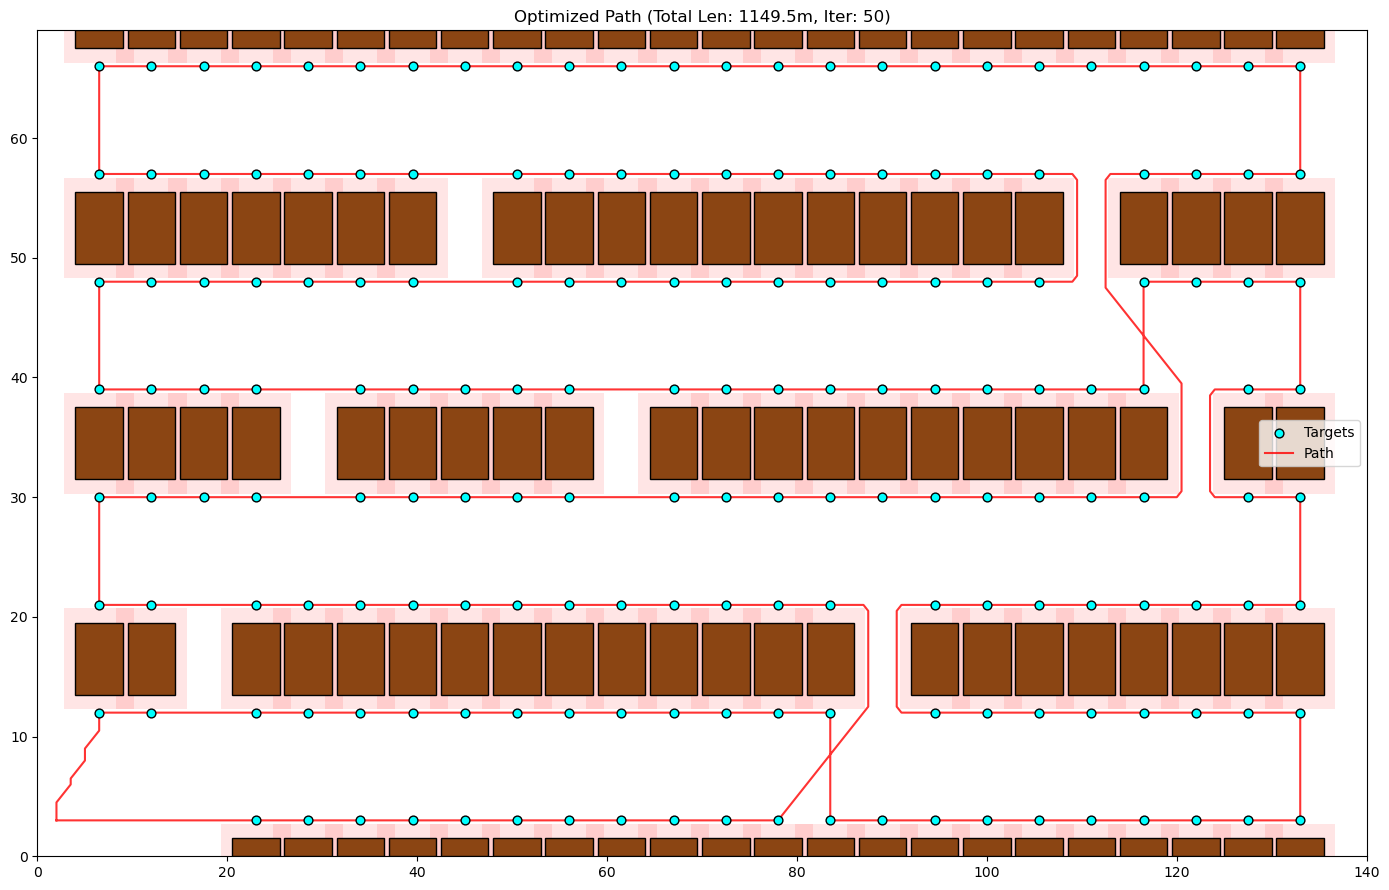

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import networkx as nx
from scipy.spatial import cKDTree

# ==========================================
# 1. 環境設定
# ==========================================
class GreenhouseSafeGrid:
    def __init__(self):
        self.width = 166
        self.height = 69.7
        self.left_margin_pots = 5.0
        self.pot_length = 6.5
        self.gap_x = 0
        self.obstacles = []
        self._build_obstacles()
        
        # [修改 1] 網格密度設細一點，比較容易找到剛好在邊緣的點
        self.GRID_RES = 0.5 
        
        # [修改 2] 安全緩衝保持 1.2m
        self.SAFETY_BUFFER = 1.2 

    def _add_pot(self, row_index, pot_index, is_double):
        single_h = 1.5
        double_h = 6.0 
        row_y_coords = [67.5, 49.5, 31.5, 13.5, 0.0]
        current_x = self.left_margin_pots + (self.pot_length + self.gap_x) * pot_index
        current_y = row_y_coords[row_index]
        current_h = double_h if is_double else single_h
        return {
            'x': current_x, 'y': current_y,
            'w': self.pot_length, 'h': current_h,
            'cx': current_x + self.pot_length / 2,
            'cy': current_y + current_h / 2,
            'is_double': is_double, 'row_idx': row_index,
            'id': f"R{row_index}_P{pot_index}"
        }

    def _build_obstacles(self):
        # ... (與原程式碼相同，省略以節省篇幅) ...
        skipped = {0: [], 1: [7, 19], 2: [4, 10, 21], 3: [2, 15], 4: [0, 1, 2]}
        for r in range(5):
            is_dbl = (r in [1, 2, 3])
            for i in range(24):
                if i in skipped.get(r, []): continue
                self.obstacles.append(self._add_pot(r, i, is_dbl))

    def _is_safe_strict(self, x, y):
        margin = self.SAFETY_BUFFER
        # 邊界檢查
        if not (margin < x < self.width-margin and margin < y < self.height-margin): return False
        # 障礙物檢查
        for ob in self.obstacles:
            if (ob['x'] - margin < x < ob['x'] + ob['w'] + margin) and \
               (ob['y'] - margin < y < ob['y'] + ob['h'] + margin):
                return False
        return True
    
    def _is_line_blocked(self, p1, p2):
        steps = 5 # 檢查密度稍微提高
        for t in np.linspace(0, 1, steps):
            px = p1[0] + (p2[0] - p1[0]) * t
            py = p1[1] + (p2[1] - p1[1]) * t
            if not self._is_safe_strict(px, py): return True
        return False

    def generate_safe_graph(self):
        G = nx.Graph()
        # 為了能更貼近盆栽，我們用更細的網格生成
        x_range = np.arange(1.0, self.width, self.GRID_RES)
        y_range = np.arange(1.0, self.height, self.GRID_RES)
        
        node_id_counter = 0
        print(f"🚧 生成網格 (Res: {self.GRID_RES}m, Buffer: {self.SAFETY_BUFFER}m)...")
        
        valid_nodes = []
        for x in x_range:
            for y in y_range:
                if self._is_safe_strict(x, y):
                    G.add_node(node_id_counter, pos=(x, y), type='connector')
                    valid_nodes.append((x, y))
                    node_id_counter += 1
        
        # 建立連線 (KDTree)
        if not valid_nodes: return G
        coords = np.array(valid_nodes)
        tree = cKDTree(coords)
        radius = self.GRID_RES * 1.5 # 允許對角線
        pairs = tree.query_pairs(r=radius)
        
        for i, j in pairs:
            p1 = G.nodes[i]['pos']
            p2 = G.nodes[j]['pos']
            if not self._is_line_blocked(p1, p2):
                dist = np.linalg.norm(np.array(p1) - np.array(p2))
                G.add_edge(i, j, weight=dist)
                
        print(f"✅ 節點數: {len(G.nodes)}")
        return G

    def identify_targets(self, G):
        target_ids = set()
        
        # [關鍵修改]：觀察距離必須 >= 安全緩衝區 + 一個微小值
        # 這樣才能確保理想點不會落在被刪除的紅區內
        offset = self.SAFETY_BUFFER + 0.1 
        
        node_ids = list(G.nodes)
        if not node_ids: return [], None
        node_coords = np.array([G.nodes[i]['pos'] for i in node_ids])
        tree = cKDTree(node_coords)
        
        for ob in self.obstacles:
            ideal_spots = []
            if ob['row_idx'] != 4: 
                ideal_spots.append((ob['cx'], ob['y'] - offset))
            if ob['is_double'] or ob['row_idx'] == 4:
                ideal_spots.append((ob['cx'], ob['y'] + ob['h'] + offset))
                
            for tx, ty in ideal_spots:
                # 搜尋最近的點
                dist, idx = tree.query((tx, ty))
                
                # 稍微放寬距離容忍度，因為網格是離散的
                # 如果找不到由 Offset 定義的點附近的網格，代表那裡可能被卡死
                if dist < 1.0: 
                    real_node_id = node_ids[idx]
                    G.nodes[real_node_id]['type'] = 'target'
                    target_ids.add(real_node_id)

        # 起點 (確保起點也是安全的)
        d, start_idx = tree.query((2.0, 3.0))
        start_id = node_ids[start_idx]
        G.nodes[start_id]['type'] = 'start'
        
        return list(target_ids), start_id

# ==========================================
# 2. ACO (完全保留你的邏輯)
# ==========================================
class HighResACO:
    def __init__(self, G, target_ids, start_id, n_ants, n_iterations):
        self.G = G
        self.target_ids = target_ids
        self.start_id = start_id
        self.all_key_nodes = [start_id] + target_ids
        self.n_ants = n_ants
        self.n_iterations = n_iterations # [注意] 這裡是控制次數的地方
        
        print("🧮 計算 Dijkstra...")
        self.dist_matrix = self._compute_key_distances()
        self.n_keys = len(self.all_key_nodes)
        self.pheromone = np.ones((self.n_keys, self.n_keys))
        self.id_to_idx = {node_id: i for i, node_id in enumerate(self.all_key_nodes)}

    def _compute_key_distances(self):
        n = len(self.all_key_nodes)
        matrix = np.full((n, n), np.inf)
        for i, source_id in enumerate(self.all_key_nodes):
            try:
                length_dict = nx.single_source_dijkstra_path_length(self.G, source_id)
                for j, target_id in enumerate(self.all_key_nodes):
                    if target_id in length_dict:
                        matrix[i][j] = length_dict[target_id]
            except: pass
        return matrix

    def run(self):
        best_tour = None
        best_len = np.inf
        
        with np.errstate(divide='ignore'):
            eta = 1.0 / self.dist_matrix
        eta[self.dist_matrix == np.inf] = 0
        
        start_idx = self.id_to_idx[self.start_id]
        
        print(f"🚀 ACO 開始 (預計執行 {self.n_iterations} 次迭代)...")
        
        for it in range(self.n_iterations):
            paths = []
            lengths = []
            for _ in range(self.n_ants):
                tour = self._construct_tour(start_idx, eta)
                if len(tour) < len(self.all_key_nodes) + 1: continue # 略過失敗的路徑
                
                l = sum([self.dist_matrix[tour[k]][tour[k+1]] for k in range(len(tour)-1)])
                paths.append(tour)
                lengths.append(l)
                if l < best_len:
                    best_len = l
                    best_tour = tour
            
            if paths:
                self._update_pheromone(paths, lengths)
            
            # [修改] 每 10 次 print 一次，最後一次也要 print
            if (it+1) % 10 == 0 or (it+1) == self.n_iterations:
                print(f"Iter {it+1}/{self.n_iterations}: Best Length = {best_len:.1f}m")
            
        return best_tour, best_len

    def _construct_tour(self, start_idx, eta):
        path = [start_idx]
        curr = start_idx
        unvisited = set(range(len(self.all_key_nodes)))
        unvisited.remove(start_idx)
        alpha, beta = 1.0, 4.0
        
        while unvisited:
            probs = []
            candidates = list(unvisited)
            for cand in candidates:
                ph = self.pheromone[curr][cand]
                he = eta[curr][cand]
                probs.append((ph**alpha) * (he**beta))
            
            probs = np.array(probs)
            if probs.sum() == 0: break
            probs /= probs.sum()
            next_idx = np.random.choice(candidates, p=probs)
            path.append(next_idx)
            unvisited.remove(next_idx)
            curr = next_idx
        path.append(start_idx)
        return path

    def _update_pheromone(self, paths, lengths):
        self.pheromone *= 0.9
        for p, l in zip(paths, lengths):
            deposit = 1000.0 / l
            for i in range(len(p)-1):
                u, v = p[i], p[i+1]
                self.pheromone[u, v] += deposit
                self.pheromone[v, u] += deposit

    def reconstruct_path(self, tour_indices):
        if tour_indices is None: return np.array([])
        coords = []
        for k in range(len(tour_indices)-1):
            u = self.all_key_nodes[tour_indices[k]]
            v = self.all_key_nodes[tour_indices[k+1]]
            path_nodes = nx.shortest_path(self.G, u, v, weight='weight')
            for nid in path_nodes[:-1]:
                coords.append(self.G.nodes[nid]['pos'])
        coords.append(self.G.nodes[self.all_key_nodes[tour_indices[-1]]]['pos'])
        return np.array(coords)

# ==========================================
# 3. 執行區塊
# ==========================================
env = GreenhouseSafeGrid()
G = env.generate_safe_graph()
targets, start_id = env.identify_targets(G)


current_iterations = 100
current_ants = 100

print(f"🎯 目標點數量: {len(targets)}")

aco = HighResACO(G, targets, start_id, n_ants=current_ants, n_iterations=current_iterations)
best_indices, best_len = aco.run()
full_path = aco.reconstruct_path(best_indices)

# --- 繪圖 ---
if len(full_path) > 0:
    fig, ax = plt.subplots(figsize=(14, 9))
    ax.set_xlim(0, 140)
    ax.set_ylim(0, 69)

    # 畫盆栽與緩衝
    for ob in env.obstacles:
        rect = patches.Rectangle((ob['x'], ob['y']), ob['w'], ob['h'], facecolor='#8B4513', edgecolor='black', zorder=5)
        ax.add_patch(rect)
        margin = env.SAFETY_BUFFER
        ax.add_patch(patches.Rectangle((ob['x']-margin, ob['y']-margin), ob['w']+2*margin, ob['h']+2*margin, 
                                     facecolor='red', alpha=0.1, zorder=2, linestyle='--'))

    # 畫目標點 (青色)
    tar_pos = np.array([G.nodes[i]['pos'] for i in targets])
    if len(tar_pos) > 0:
        ax.scatter(tar_pos[:,0], tar_pos[:,1], c='cyan', s=40, edgecolors='black', zorder=15, label='Targets')

    # 畫路徑
    ax.plot(full_path[:,0], full_path[:,1], c='red', linewidth=1.5, alpha=0.8, zorder=10, label='Path')

    plt.title(f"Optimized Path (Total Len: {best_len:.1f}m, Iter: {current_iterations})")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("❌ 未能找到完整路徑 (可能因為安全邊界太嚴格導致路徑中斷)")